In [1]:
!pip install pandas numpy

In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r'C:\Users\Admin\Desktop\food_allergen_detection\datasets\Allergen_Status_of_Food_Products.csv',na_values=[""],keep_default_na=False)

In [5]:
df.head(10)

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Price ($),Customer rating (Out of 5),Prediction
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",10.15,3.1,Contains
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",6.17,4.5,Contains
2,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",19.65,4.1,Contains
3,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",17.48,4.7,Contains
4,Cheddar Cheese,Cheese,None,None,Salt,Dairy,10.83,3.7,Contains
5,Ranch Dressing,Buttermilk,Sugar,Vegetable oil,"Garlic, herbs",Dairy,9.92,2.3,Contains
6,Caramel Popcorn,Popcorn,Sugar,Butter,Salt,Dairy,6.14,3.2,Contains
7,Caesar Salad,Romaine lettuce,None,Olive oil,Parmesan cheese,Dairy,14.99,4.8,Contains
8,Caesar Wrap,Grilled chicken,None,Caesar dressing,"Lettuce, Parmesan cheese",Dairy,12.45,3.8,Contains
9,Strawberry Smoothie,Strawberries,Honey,"Yogurt (milk, cultures)",None,Dairy,13.37,3.2,Contains


## Exploratory Data Analysis

In [6]:
df.shape

(399, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Food Product                399 non-null    object 
 1   Main Ingredient             399 non-null    object 
 2   Sweetener                   399 non-null    object 
 3   Fat/Oil                     399 non-null    object 
 4   Seasoning                   399 non-null    object 
 5   Allergens                   399 non-null    object 
 6   Price ($)                   399 non-null    float64
 7   Customer rating (Out of 5)  399 non-null    float64
 8   Prediction                  398 non-null    object 
dtypes: float64(2), object(7)
memory usage: 28.2+ KB


In [8]:
df.describe()

,Price ($),Customer rating (Out of 5)
count,399.000000,399.000000
mean,12.402356,2.991228
std,4.368315,1.171049
min,5.070000,1.000000
25%,8.650000,1.900000
50%,12.470000,3.100000
75%,16.105000,4.000000
max,19.930000,5.000000


In [9]:
df.isnull().sum()

Food Product                  0
Main Ingredient               0
Sweetener                     0
Fat/Oil                       0
Seasoning                     0
Allergens                     0
Price ($)                     0
Customer rating (Out of 5)    0
Prediction                    1
dtype: int64

In [10]:
df_unique = df.apply(lambda x: len(x.unique()))
#unique values in each column
df_unique

Food Product                  259
Main Ingredient               101
Sweetener                      10
Fat/Oil                        36
Seasoning                     186
Allergens                      40
Price ($)                     345
Customer rating (Out of 5)     41
Prediction                      3
dtype: int64

In [11]:
#rename the columns
df = df.rename(columns={'Customer rating (Out of 5)': 'Customer rating', 'Price ($)':'Price'})

In [12]:
df.head()

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Price,Customer rating,Prediction
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",10.15,3.1,Contains
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",6.17,4.5,Contains
2,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",19.65,4.1,Contains
3,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",17.48,4.7,Contains
4,Cheddar Cheese,Cheese,None,None,Salt,Dairy,10.83,3.7,Contains


In [13]:
#the value counts of each allergens
df['Allergens'].value_counts()

Allergens
None                      148
Dairy                      83
Wheat, Dairy               72
Soybeans                    8
Wheat                       8
Fish                        7
Shellfish, Dairy            6
Fish, Soybeans              6
Shellfish                   6
Peanuts                     5
Milk                        4
Wheat, Dairy, Nuts          3
Eggs                        3
Dairy, Wheat                3
Pine nuts, Dairy            3
Almonds, Wheat, Dairy       2
Wheat, Dairy, Eggs          2
Wheat, Dairy, Cocoa         2
Fish, Eggs                  2
Shellfish, Eggs             2
Milk, Strawberries          2
Chicken, Wheat, Celery      2
Fish, Dairy                 2
Dairy, Nuts                 2
Dairy, Ghee                 1
Dairy, Fish                 1
Dairy, Eggs                 1
Dairy, Cocoa                1
Dairy, Anchovies            1
Eggs, Dairy                 1
Eggs, Soybeans              1
Fish, Coconut               1
Oats, Dairy                 1


In [14]:
#finding min and max prices
print(df['Price'].max())
print(df['Price'].min())

19.93
5.07


## Data Visualization

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


#### 1. Customer Rating Distribution: Shows how customer ratings are distributed.

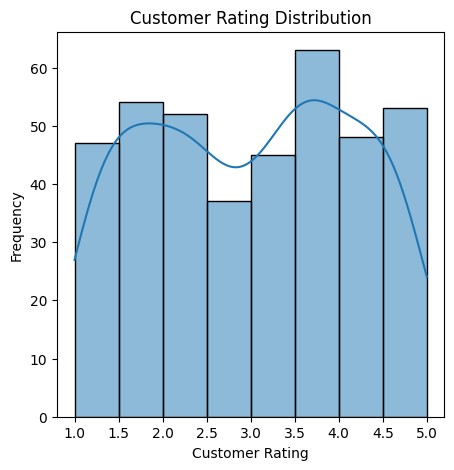

In [16]:
#histogram for Customer Rating distribution
plt.figure(figsize=(5,5))
sns.histplot(df['Customer rating'], bins=8, kde=True)
plt.title('Customer Rating Distribution')
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')
plt.show()

The histogram shows that the most products received customer ratings around 3.5, indicating a general level of satisfaction. Fewer products received extreme ratings (very low or very high). Distribution slightly skewed right, suggesting a few products with exceptionally high ratings. Overall, general satisfaction with products, but with a range of opinions.

#### 2. Count of Products by Allergen Prediction: A bar chart showing the number of products with and without allergens

In [17]:
allergen_counts = df['Prediction'].value_counts()
allergen_counts

Prediction
Contains            255
Does not contain    143
Name: count, dtype: int64

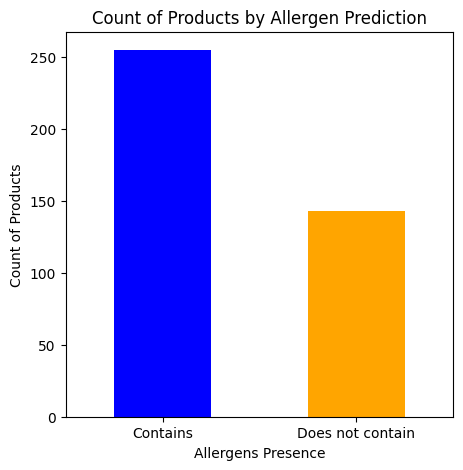

In [18]:
#count of products by Allergen Prediction
plt.figure(figsize=(5, 5))
allergen_counts.plot(kind='bar', color=['blue', 'orange'],)
plt.title('Count of Products by Allergen Prediction')
plt.xlabel('Allergens Presence')
plt.ylabel('Count of Products')
plt.xticks(rotation=0)
plt.show()

The bar chart shows the number of products that contain or do not contain allergens. Most products contain allergens, while fewer products do not.

#### 3. Price Distribution by Allergen Presence: A box plot displaying the price ranges for products with and without allergens.

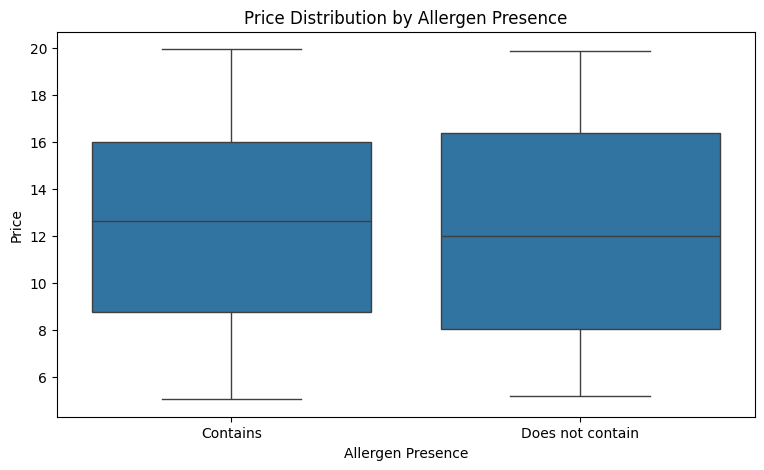

In [19]:
#box plot for displaying price ranges of productss with and without allergens
plt.figure(figsize=(9,5))
sns.boxplot(x='Prediction', y='Price', data=df)
plt.title('Price Distribution by Allergen Presence')
plt.xlabel('Allergen Presence')
plt.ylabel('Price')
plt.show()

The box plot shows that the median price for products that contain allergens is slightly higher than the median price for products that do not contain allergens. However, there is also a significant overlap between the two groups, indicating that price is not solely determined by the presence or absence of allergens.

#### 4. Top 10 Most Common Main Ingredients: Showing the most common ingredients used in the food products.

In [20]:
ingredient_count=df['Main Ingredient'].value_counts().head(10)
ingredient_count

Main Ingredient
Chicken             61
Flour               16
Beef                15
Pasta               14
Tomatoes            12
Apples              12
Spinach             11
Shrimp              10
Mixed vegetables     8
Pizza dough          7
Name: count, dtype: int64

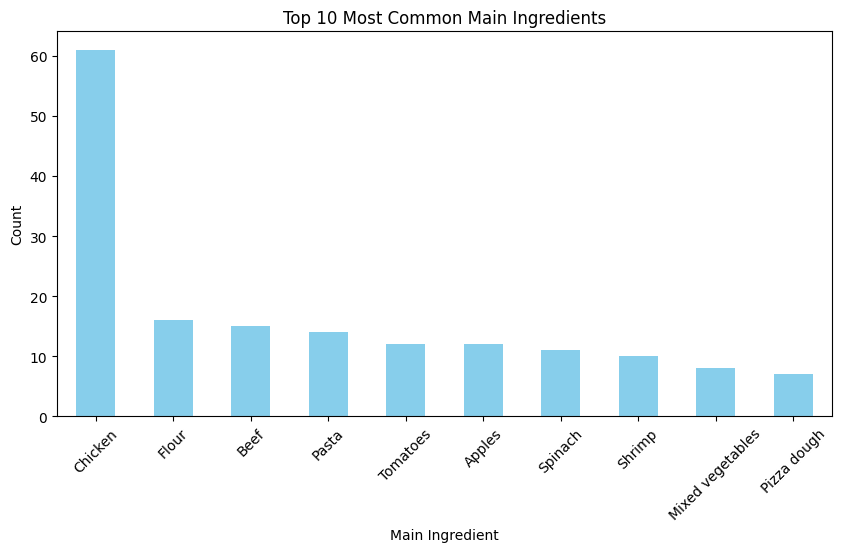

In [21]:
#bar plot to show the most common ingredients used in the food products
plt.figure(figsize=(10, 5))
ingredient_count.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Common Main Ingredients')
plt.xlabel('Main Ingredient')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The bar chart shows the frequency of the 10 most common main ingredients in the dataset. The x-axis represents the main ingredients, and the y-axis represents the count. The chart shows that chicken is the most common main ingredient, followed by flour, beef, pasta, and tomatoes. The other main ingredients, such as apples, spinach, shrimp, mixed vegetables, and pizza dough, have lower frequencies.

#### 5. Top 10 Most Frequent Allergens: Displaying the most common allergens

In [22]:
#split and count the allergens in each record
allergen_counts=df['Allergens'].str.split(', ', expand=True).stack()
top_allergens=allergen_counts.value_counts().head(10)
top_allergens

Dairy        190
None         148
Wheat         96
Fish          20
Soybeans      17
Shellfish     16
Eggs          13
Milk           6
Nuts           5
Peanuts        5
Name: count, dtype: int64

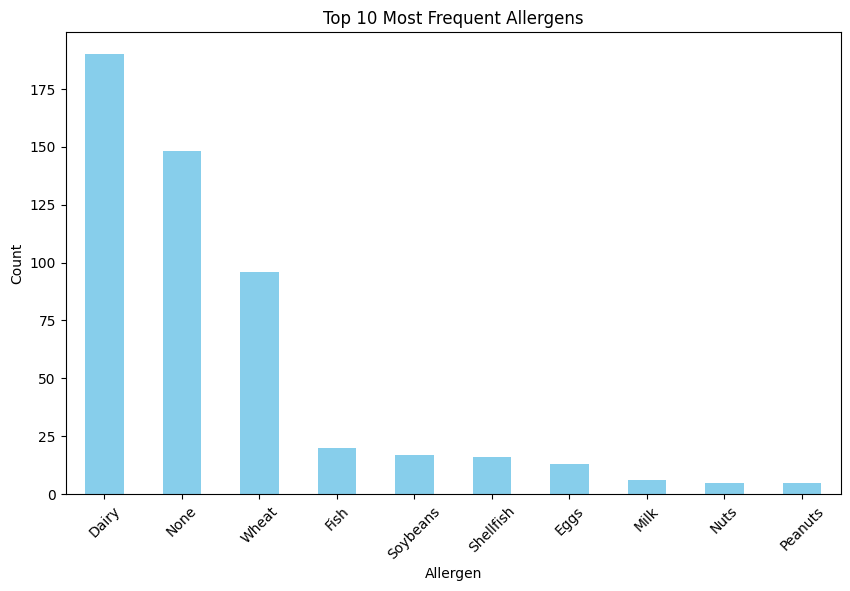

In [23]:
#bar plot to show Top 10 Most Frequent Allergens
plt.figure(figsize=(10, 6))
top_allergens.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Frequent Allergens')
plt.xlabel('Allergen')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

This bar chart shows the frequency of the 10 most common allergens in the dataset. The x-axis represents the allergens, and the y-axis represents the count. The chart shows that dairy is the most common allergen, followed by none, wheat, fish, and soybeans. The other allergens, such as shellfish, eggs, milk, nuts, and peanuts, have lower frequencies.

#### 6. Number of Records by predictions for the Allergen 'None'

In [24]:
# Filter records where Allergens is 'None'
none_allergens_df = df[df['Allergens'] == 'None']

# Count the occurrences of Prediction values
prediction_counts = none_allergens_df['Prediction'].value_counts()

prediction_counts

Prediction
Does not contain    143
Contains              5
Name: count, dtype: int64

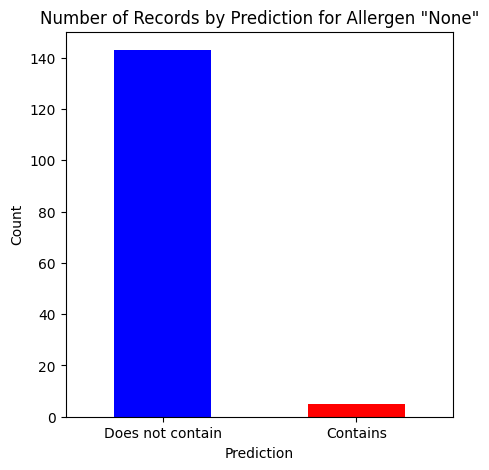

In [25]:
# Bar chart
plt.figure(figsize=(5,5))
prediction_counts.plot(kind='bar',color=['blue', 'red'])
plt.title('Number of Records by Prediction for Allergen "None"')
plt.xlabel('Prediction')
plt.ylabel('Count')
plt.xticks( rotation=0)
plt.show()

This bar chart shows the number of records that were predicted to contain or not contain the allergen, when the allergens are shown as none in the dataset.The chart shows that a significantly higher number of products were predicted to not contain the allergen when the allergens column shows "None" compared to those predicted to contain it,when the allergens column shows "None".

#### 7.Customer Ratings vs. Allergen Count

In [26]:
# Function to count the number of allergens
def count_allergens(allergens):
    return len(allergens.split(', '))

# Apply the function to count allergens
df['Allergen Count'] = df['Allergens'].apply(count_allergens)

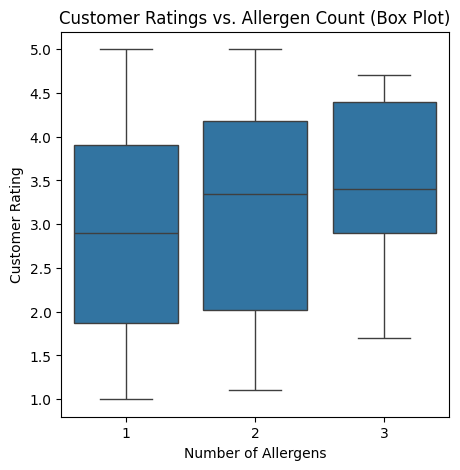

In [27]:
# Box plot to visualize the relationship between Allergen Count and Customer Rating
plt.figure(figsize=(5, 5))
sns.boxplot(x='Allergen Count', y='Customer rating', data=df)
plt.xlabel('Number of Allergens')
plt.ylabel('Customer Rating')
plt.title('Customer Ratings vs. Allergen Count (Box Plot)')
plt.show()

This box plot shows the relationship between the number of allergens in a food product and its customer rating. The x-axis represents the number of allergens, while the y-axis represents the customer rating. The median ratings for products with 1, 2, and 3 allergens are relatively close, indicating no strong correlation between the number of allergens and customer ratings. The ratings' spread suggests significant variation in customer opinions, regardless of allergen count. This indicates that the presence of allergens may not significantly impact customer perception and satisfaction in this dataset.

#### 8.Correlation Matrix

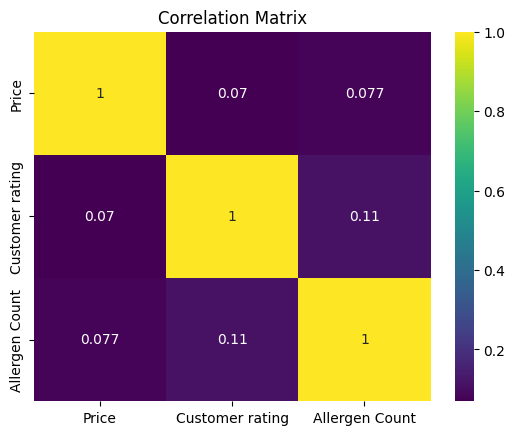

In [28]:
# Calculate correlation matrix
correlation_matrix = df[['Price', 'Customer rating', 'Allergen Count']].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

This heatmap shows the correlation between the price, customer rating, and allergen count of the food products. The x-axis and y-axis represent the features, and the color of each cell indicates the strength and direction of the correlation. A dark blue cell indicates a strong negative correlation, a dark yellow cell indicates a strong positive correlation, and a white cell indicates no correlation.

From the heatmap, we can see that there is a weak positive correlation between price and customer rating, meaning that slightly higher-priced products tend to have slightly higher ratings. There is also a weak negative correlation between allergen count and customer rating, suggesting that products with fewer allergens tend to have slightly higher ratings. However, the correlation between price and allergen count is very weak, indicating that there is no significant relationship between these two features.

In [29]:
import plotly.express as px

In [30]:
import plotly
print(plotly.__version__)

5.24.1


In [31]:
fig = px.scatter(df, x='Price', y='Customer rating',
                hover_data=['Main Ingredient', 'Allergen Count'],title="Customer Rating vs. Price")
fig.show()

In [32]:
fig = px.bar(df['Main Ingredient'].value_counts().reset_index(),
            x='Main Ingredient', y='count',
            hover_data=['Main Ingredient'])
fig.show()

In [33]:
fig = px.scatter_3d(df, x='Price', y='Customer rating', z='Allergen Count',
                   color='Prediction')
fig.show()

## Data Preprocessing

### Handling Missing Values

In [34]:
#handlling missing values
df.isnull().sum()

Food Product       0
Main Ingredient    0
Sweetener          0
Fat/Oil            0
Seasoning          0
Allergens          0
Price              0
Customer rating    0
Prediction         1
Allergen Count     0
dtype: int64

In [35]:
df.dropna(inplace=True)

There is a NaN value in the predction column.so that row is dropped from the datasetand the original dataset is replaced with the new dataset without any NaN values.

In [36]:
df.isnull().sum()

Food Product       0
Main Ingredient    0
Sweetener          0
Fat/Oil            0
Seasoning          0
Allergens          0
Price              0
Customer rating    0
Prediction         0
Allergen Count     0
dtype: int64

### Handling Duplicates

In [37]:
#handling duplicates
duplicate_rows = df[df.duplicated()]
duplicate_rows

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Price,Customer rating,Prediction,Allergen Count


In [38]:
duplicate_rows.sum()

Food Product         0
Main Ingredient      0
Sweetener            0
Fat/Oil              0
Seasoning            0
Allergens            0
Price              0.0
Customer rating    0.0
Prediction           0
Allergen Count       0
dtype: object

There are no duplicates in the Dataset.

### Handling Outliers

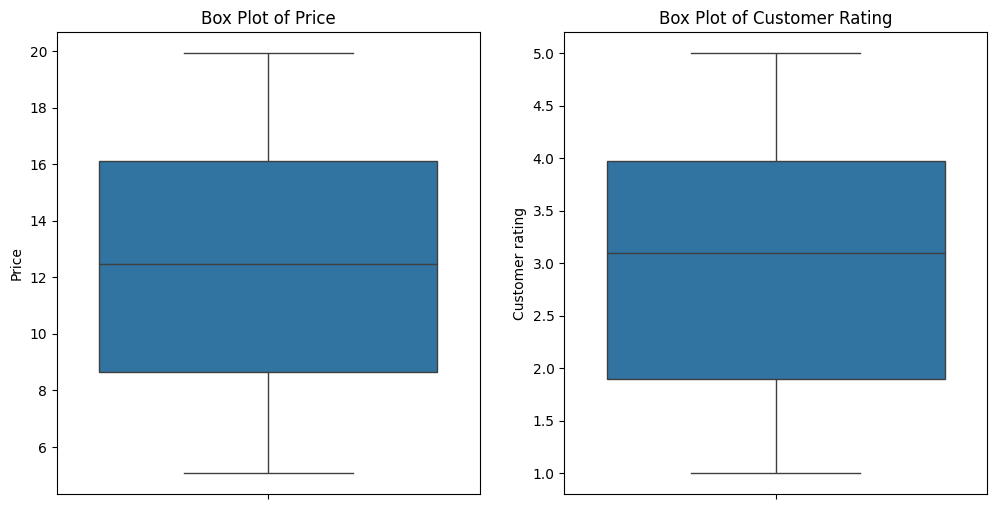

In [39]:
# Visualize the 'Price' and 'Customer rating' columns
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Price'])
plt.title('Box Plot of Price')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Customer rating'])
plt.title('Box Plot of Customer Rating')

plt.show()

In [40]:
#identifying outliers using IQR method
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

price_outliers = find_outliers_iqr(df['Price'])
rating_outliers = find_outliers_iqr(df['Customer rating'])

print("Price Outliers:\n", price_outliers)
print("Customer Rating Outliers:\n", rating_outliers)


Price Outliers:
 Series([], Name: Price, dtype: float64)
Customer Rating Outliers:
 Series([], Name: Customer rating, dtype: float64)


There are no outliers in the dataset.

### Encoding Categorical Data

In [41]:
from sklearn.preprocessing import  MultiLabelBinarizer, LabelEncoder

In [42]:
df.head()

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Price,Customer rating,Prediction,Allergen Count
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",10.15,3.1,Contains,3
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",6.17,4.5,Contains,3
2,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",19.65,4.1,Contains,3
3,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",17.48,4.7,Contains,3
4,Cheddar Cheese,Cheese,None,None,Salt,Dairy,10.83,3.7,Contains,1


#### Label Encoding for Prediction Column

In [43]:
# Label Encoding for the 'Prediction' column
label_encoder = LabelEncoder()
df['Prediction'] = label_encoder.fit_transform(df['Prediction'])

In [44]:
df.head()

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Price,Customer rating,Prediction,Allergen Count
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",10.15,3.1,0,3
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",6.17,4.5,0,3
2,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",19.65,4.1,0,3
3,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",17.48,4.7,0,3
4,Cheddar Cheese,Cheese,None,None,Salt,Dairy,10.83,3.7,0,1


In [45]:
df['Prediction'].value_counts()

Prediction
0    255
1    143
Name: count, dtype: int64

Here 0 represents contains and 1 represents doesnot contain values in the prediction column.

In [46]:
df.head()

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Price,Customer rating,Prediction,Allergen Count
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",10.15,3.1,0,3
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",6.17,4.5,0,3
2,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",19.65,4.1,0,3
3,Chicken Noodle Soup,Chicken broth,None,None,Salt,"Chicken, Wheat, Celery",17.48,4.7,0,3
4,Cheddar Cheese,Cheese,None,None,Salt,Dairy,10.83,3.7,0,1


In [47]:
# Drop the "Allergen Count" column
df = df.drop(columns=["Allergen Count"])


#### Leave One Out Encoding for Nominal Columns

In [48]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [49]:
import category_encoders as ce

In [50]:
# Leave one out encoding for specified column
categorical_columns = ['Food Product', 'Main Ingredient', 'Sweetener', 'Fat/Oil', 'Seasoning','Allergens']

# Initialize LeaveOneOutEncoder
encoder = ce.LeaveOneOutEncoder(cols=categorical_columns)

# Apply the encoder
df_encoded = encoder.fit_transform(df[categorical_columns], df['Price'])

# Replace the original categorical columns with their encoded counterparts
df = pd.concat([df.drop(columns=categorical_columns), df_encoded], axis=1)


# Display the dataframe with LOO encoding
print(df.head())

   Price  Customer rating  Prediction  Food Product  Main Ingredient  \
0  10.15              3.1           0      6.170000            6.170   
1   6.17              4.5           0     10.150000           10.150   
2  19.65              4.1           0     12.500000           17.480   
3  17.48              4.7           0     13.223333           19.650   
4  10.83              3.7           0     12.397588           17.925   

   Sweetener    Fat/Oil  Seasoning  Allergens  
0  12.343736  12.471786     13.408   6.170000  
1  12.387473  12.519167     13.806  10.150000  
2  12.371511  12.031228     11.584  17.480000  
3  12.379317  12.069298     11.801  19.650000  
4  12.403237  12.185965     12.466  12.072073  


In [51]:
df.head()

,Price,Customer rating,Prediction,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens
0,10.15,3.1,0,6.170000,6.170,12.343736,12.471786,13.408,6.170000
1,6.17,4.5,0,10.150000,10.150,12.387473,12.519167,13.806,10.150000
2,19.65,4.1,0,12.500000,17.480,12.371511,12.031228,11.584,17.480000
3,17.48,4.7,0,13.223333,19.650,12.379317,12.069298,11.801,19.650000
4,10.83,3.7,0,12.397588,17.925,12.403237,12.185965,12.466,12.072073


### Saving the data into CSV file

In [52]:
output_path='C:/Users/Admin/Desktop/food_allergen_detection/datasets/output_dataset.csv'

# Write the DataFrame to a CSV file
df.to_csv(output_path, index=False)

### Saving the Encoder

In [53]:
import joblib
import os

In [54]:
encoder_path ='C:/Users/Admin/Desktop/food_allergen_detection/Models/encoder.pkl'

#save the encoder
joblib.dump(encoder, encoder_path)

print(f"Encoder saved to {encoder_path}")

Encoder saved to C:/Users/Admin/Desktop/food_allergen_detection/Models/encoder.pkl


## Training the Model

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [56]:
# Define the target variable
target = 'Prediction'

# Separate the features and target variable
X = df.drop(columns=[target])
y = df[target]

In [57]:
# Print the shape of X and y
print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# Display the first few rows of X and y to verify the split
print("\nFeatures (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Shape of features (X): (398, 8)
Shape of target (y): (398,)

Features (X):
   Price  Customer rating  Food Product  Main Ingredient  Sweetener  \
0  10.15              3.1      6.170000            6.170  12.343736   
1   6.17              4.5     10.150000           10.150  12.387473   
2  19.65              4.1     12.500000           17.480  12.371511   
3  17.48              4.7     13.223333           19.650  12.379317   
4  10.83              3.7     12.397588           17.925  12.403237   

     Fat/Oil  Seasoning  Allergens  
0  12.471786     13.408   6.170000  
1  12.519167     13.806  10.150000  
2  12.031228     11.584  17.480000  
3  12.069298     11.801  19.650000  
4  12.185965     12.466  12.072073  

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: Prediction, dtype: int64


In [58]:
# Splitting into training and testing sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [59]:
#Printing the shapes of the resulting datasets
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (278, 8)
Shape of X_test: (120, 8)
Shape of y_train: (278,)
Shape of y_test: (120,)


In [60]:
X_train.head()

,Price,Customer rating,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens
157,6.34,3.1,12.397588,11.913500,12.419388,13.169888,12.397588,12.205238
109,11.70,4.5,9.550000,12.446000,12.400108,13.109663,10.360000,9.028333
17,17.33,3.1,14.990000,14.385000,12.379856,13.046404,12.595000,11.992805
253,7.47,2.4,18.760000,15.433636,12.415324,12.244912,18.760000,12.197551
24,11.07,4.4,15.675000,11.834667,12.402374,12.397588,12.397588,12.069146
